In [1]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*FigureCanvasAgg is non-interactive.*"
)
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#569CC6", "#D55F03"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [3]:
import sys
!{sys.executable} -m pip install tsfeatures

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for supersmoother: filename=supersmoother-0.4-py3-none-any.whl size=16155 sha256=6c70380e51e0ff375bd0a8e5ca5ca7b774be36389d44558ff93815922afe99d0
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\69\4a\ff\05c85ded597955df839bedebe6dca56297c2568c04881d2e70
Successfully built supersmoother

   ---------------------------------------- 0/3 [supersmoother]
   ---------------------------------------- 0/3 [supersmoother]
   ---------------------------------------- 0/3 [supersmoother]
   ---------------------------------------- 0/3 [supersmoother]
   ---------------------------------------- 0/3 [supersmoother]
   ------------- -------------------------- 1/3 [antropy]
   ------------- -------------------------- 1/3 [antropy]
   -------------------------- ------------- 2/3 [tsfeatures]
   -------------------------- ------------- 2/3 [tsfeatures]
   ---------------

  DEPRECATION: Building 'supersmoother' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'supersmoother'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import tsfeatures as tsf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

mpl.rcParams['axes.prop_cycle'] = cycler(color=["#D55F03", "#569CC6", "#13A076", "#CC79A7"])

In [6]:
aus_tourism = pd.read_csv("aus_tourism.csv", parse_dates=["ds"])
mean_df = aus_tourism.groupby("unique_id", as_index=False)["y"].mean()
mean_df.sort_values(by="y").head(10)

,unique_id,y
158,Kangaroo Island-South Australia-Other,0.340
182,MacDonnell-Northern Territory-Other,0.449
294,Wilderness West-Tasmania-Other,0.478
34,Barkly-Northern Territory-Other,0.632
86,Clare Valley-South Australia-Other,0.898
38,Barossa-South Australia-Other,1.022
154,Kakadu Arnhem-Northern Territory-Other,1.043
170,Lasseter-Northern Territory-Other,1.136
298,Wimmera-Victoria-Other,1.146
183,MacDonnell-Northern Territory-Visiting,1.175


In [7]:
summary_stats = tsf.tsfeatures(aus_tourism,
    freq=4, features=[tsf.statistics], scale=False)
summary_stats[["unique_id", "min", "p25", "median", "p75", "max"]].head(10)

,unique_id,min,p25,median,p75,max
0,Adelaide Hills-South Australia-Business,0.000,0.000,1.255,3.920,28.602
1,Adelaide Hills-South Australia-Holiday,0.000,5.768,8.516,14.060,35.751
2,Adelaide Hills-South Australia-Other,0.000,0.000,0.908,2.093,8.953
3,Adelaide Hills-South Australia-Visiting,0.778,8.908,12.207,16.806,81.102
4,Adelaide-South Australia-Business,68.725,133.893,152.577,176.936,242.494
5,Adelaide-South Australia-Holiday,108.033,134.627,153.945,172.257,223.557
6,Adelaide-South Australia-Other,25.902,43.866,53.809,62.523,107.495
7,Adelaide-South Australia-Visiting,136.611,178.916,205.582,229.299,269.536
8,Alice Springs-Northern Territory-Business,1.008,9.133,13.324,18.456,34.077
9,Alice Springs-Northern Territory-Holiday,2.809,16.851,31.524,44.784,76.541


In [8]:
acf_feat = tsf.tsfeatures(aus_tourism, freq=4, features=[tsf.acf_features])
acf_feat.head(10).iloc[:, :5]

,unique_id,x_acf1,x_acf10,diff1_acf1,diff1_acf10
0,Adelaide Hills-South Australia-Business,0.071,0.134,-0.580,0.415
1,Adelaide Hills-South Australia-Holiday,0.131,0.313,-0.536,0.500
2,Adelaide Hills-South Australia-Other,0.261,0.330,-0.253,0.317
3,Adelaide Hills-South Australia-Visiting,0.139,0.117,-0.472,0.239
4,Adelaide-South Australia-Business,0.033,0.131,-0.520,0.463
5,Adelaide-South Australia-Holiday,0.046,0.372,-0.343,0.614
6,Adelaide-South Australia-Other,0.517,1.154,-0.409,0.383
7,Adelaide-South Australia-Visiting,0.068,0.294,-0.394,0.452
8,Alice Springs-Northern Territory-Business,0.217,0.367,-0.500,0.381
9,Alice Springs-Northern Territory-Holiday,-0.007,2.113,-0.153,2.113


In [9]:
stl_feat = tsf.tsfeatures(aus_tourism, freq=4, features=[tsf.stl_features])
stl_feat.head(10).iloc[:, :5]

,unique_id,nperiods,seasonal_period,trend,spike
0,Adelaide Hills-South Australia-Business,1,4,0.460,3.223e-04
1,Adelaide Hills-South Australia-Holiday,1,4,0.531,1.048e-04
2,Adelaide Hills-South Australia-Other,1,4,0.590,5.346e-05
3,Adelaide Hills-South Australia-Visiting,1,4,0.487,5.798e-04
4,Adelaide-South Australia-Business,1,4,0.462,9.712e-05
5,Adelaide-South Australia-Holiday,1,4,0.578,1.717e-05
6,Adelaide-South Australia-Other,1,4,0.746,2.364e-05
7,Adelaide-South Australia-Visiting,1,4,0.449,4.824e-05
8,Alice Springs-Northern Territory-Business,1,4,0.552,5.246e-05
9,Alice Springs-Northern Territory-Holiday,1,4,0.379,6.707e-06


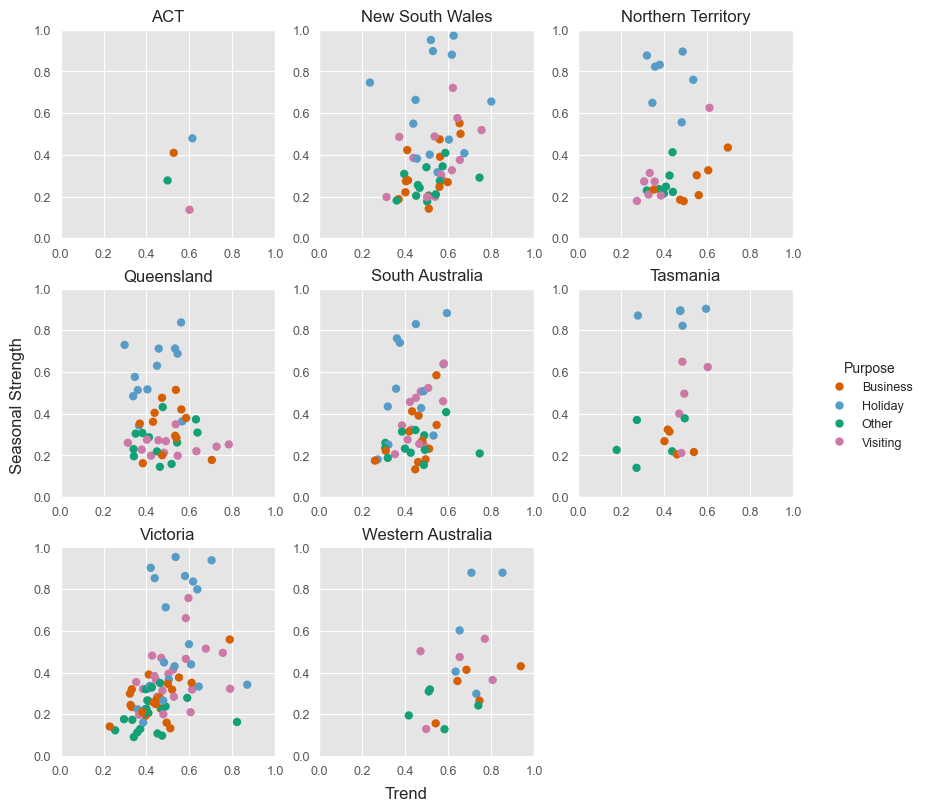

In [10]:
df = (
    stl_feat["unique_id"].str.split("-", expand=True)
    .rename(columns={0: "region", 1: "state", 2: "purpose"})
    .join(stl_feat)
)

fig, axs = plt.subplots(3, 3, figsize=(8, 8))
axs = axs.flatten()
for ax, (state, state_df) in zip(axs, df.groupby('state')):
    sns.scatterplot(x="trend", y="seasonal_strength",
        hue="purpose", edgecolor="none", data=state_df, ax=ax)
    ax.get_legend().remove()
    ax.set(title=state, xlabel="", ylabel="", xlim=(0, 1), ylim=(0, 1))

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
    title="Purpose", loc="center left", frameon=False,
    bbox_to_anchor=(1.02, .5), borderaxespad=0)

fig.supxlabel('Trend')
fig.supylabel('Seasonal Strength')

# Remove any empty subplots
for ax in axs:
    if not ax.lines:
        ax.set_visible(False)

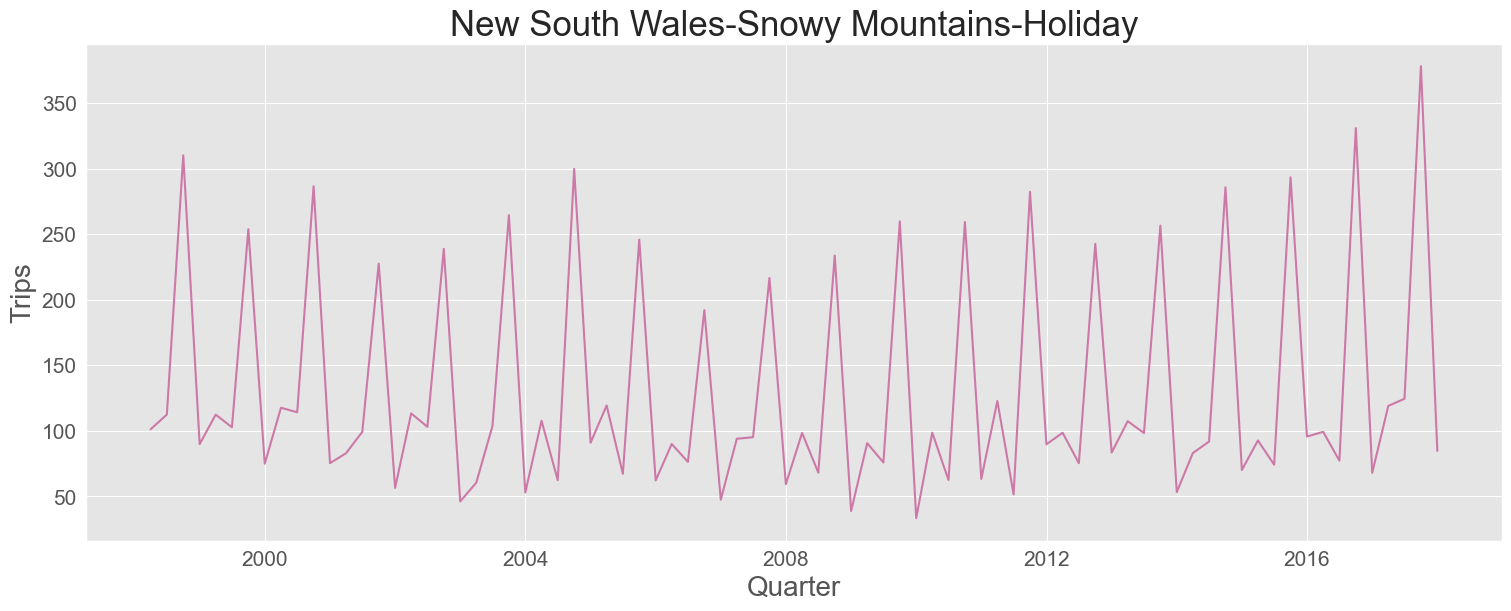

In [11]:
row = stl_feat.loc[lambda x: x["seasonal_strength"].idxmax()]
plot_series(
    aus_tourism, ids=[row["unique_id"]],
    xlabel="Quarter", ylabel="Trips",
    title="New South Wales-Snowy Mountains-Holiday")

In [12]:
all_features = [
    tsf.acf_features,
    tsf.arch_stat,
    tsf.crossing_points,
    tsf.entropy,
    tsf.flat_spots,
    tsf.heterogeneity,
    tsf.holt_parameters,
    tsf.lumpiness,
    tsf.nonlinearity,
    tsf.pacf_features,
    tsf.stl_features,
    tsf.stability,
    tsf.hw_parameters,
    tsf.unitroot_kpss,
    tsf.unitroot_pp,
    tsf.series_length,
    tsf.hurst,
]
all_feat = tsf.tsfeatures(aus_tourism, freq=4, features=all_features)
all_feat.head(10)

,unique_id,hurst,series_length,unitroot_pp,unitroot_kpss,hw_alpha,hw_beta,hw_gamma,stability,nperiods,...,entropy,crossing_points,arch_lm,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,Adelaide Hills-South Australia-Business,NaN,80,-80.527,0.060,1.490e-08,1.220e-08,0.00,0.294,1,...,0.895,36,0.014,0.071,0.134,-0.580,0.415,-0.750,0.746,-0.063
1,Adelaide Hills-South Australia-Holiday,0.823,80,-74.302,0.476,9.899e-02,9.899e-02,0.00,0.409,1,...,0.831,33,0.121,0.131,0.313,-0.536,0.500,-0.716,0.906,0.208
2,Adelaide Hills-South Australia-Other,0.599,80,-55.385,0.605,1.490e-08,1.481e-08,0.18,0.274,1,...,0.862,37,0.265,0.261,0.330,-0.253,0.317,-0.457,0.392,0.075
3,Adelaide Hills-South Australia-Visiting,0.757,80,-71.076,0.749,1.490e-08,1.150e-09,0.00,0.333,1,...,0.907,25,0.005,0.139,0.117,-0.472,0.239,-0.626,0.408,0.170
4,Adelaide-South Australia-Business,0.840,80,-78.764,0.221,1.306e-01,1.306e-01,0.00,0.318,1,...,0.848,43,0.183,0.033,0.131,-0.520,0.463,-0.676,0.741,0.201
5,Adelaide-South Australia-Holiday,0.709,80,-72.567,0.449,1.758e-01,1.758e-01,0.00,0.312,1,...,0.737,36,0.161,0.046,0.372,-0.343,0.614,-0.487,0.558,0.351
6,Adelaide-South Australia-Other,0.776,80,-36.405,1.406,1.068e-01,7.715e-02,0.00,0.574,1,...,0.755,28,0.456,0.517,1.154,-0.409,0.383,-0.675,0.792,0.342
7,Adelaide-South Australia-Visiting,0.737,80,-74.137,0.264,1.630e-01,0.000e+00,0.00,0.267,1,...,0.776,42,0.173,0.068,0.294,-0.394,0.452,-0.518,0.447,0.345
8,Alice Springs-Northern Territory-Business,0.673,80,-65.845,0.807,1.456e-01,0.000e+00,0.00,0.439,1,...,0.851,33,0.425,0.217,0.367,-0.500,0.381,-0.658,0.587,0.315
9,Alice Springs-Northern Territory-Holiday,0.579,80,-54.382,0.387,1.490e-08,7.911e-09,0.00,0.084,1,...,0.412,40,0.304,-0.007,2.113,-0.153,2.113,-0.274,1.551,0.729


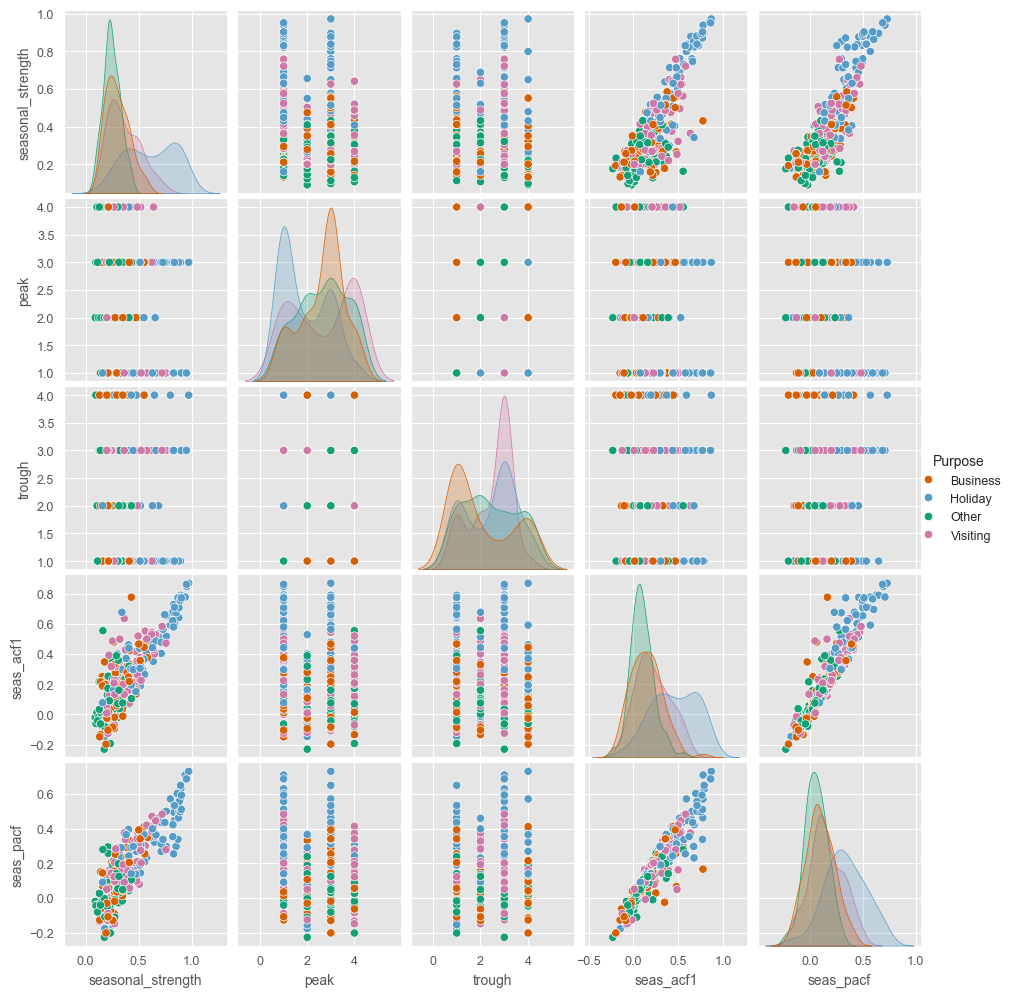

In [13]:
seasonal_feat = all_feat[
    ["unique_id", "seasonal_strength", "peak", "trough",
     "seas_acf1", "seas_pacf"]
]

df = (
    seasonal_feat["unique_id"].str.split("-", expand=True)
    .rename(columns={0: "region", 1: "state", 2: "Purpose"})
    .join(seasonal_feat)
)
g = sns.pairplot(df, hue="Purpose")
g.fig.set_size_inches(10, 10)
plt.show()

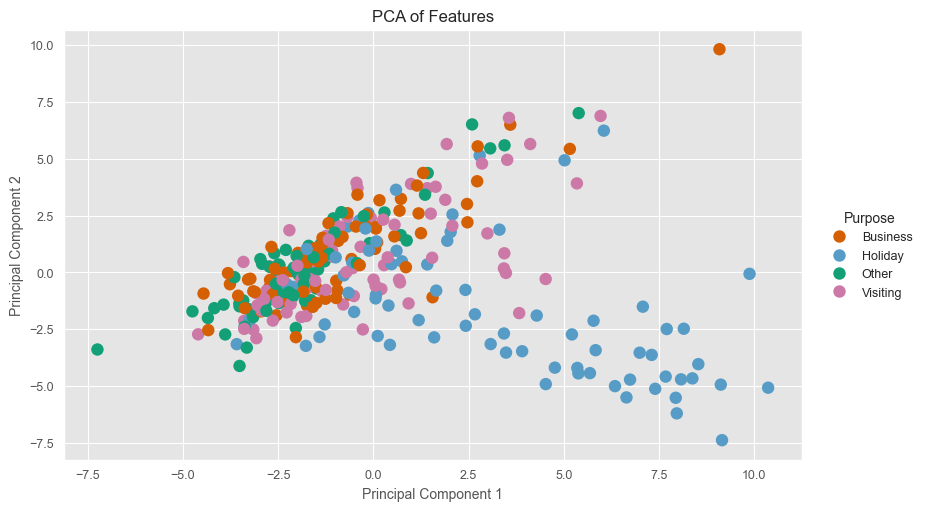

In [14]:
df = (
    all_feat
    .assign(purpose=lambda x: x["unique_id"].str.split("-").str[-1])
    .dropna(axis='columns')
)
X = df.drop(columns=["unique_id", "purpose"])

pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=2)),
])
principal_components = pipeline.fit_transform(X)

pca_df = (
    pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])
    .join(df[["unique_id", "purpose"]])
)

fig, ax = plt.subplots()
sns.scatterplot(x="PC1", y="PC2", s=80,
    hue="purpose", edgecolor="none", data=pca_df, ax=ax)
ax.set(
    title="PCA of Features",
    xlabel="Principal Component 1",
    ylabel="Principal Component 2",
)
ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
    title="Purpose", loc="center left", frameon=False,
    bbox_to_anchor=(1.02, .5), borderaxespad=0)
plt.show()

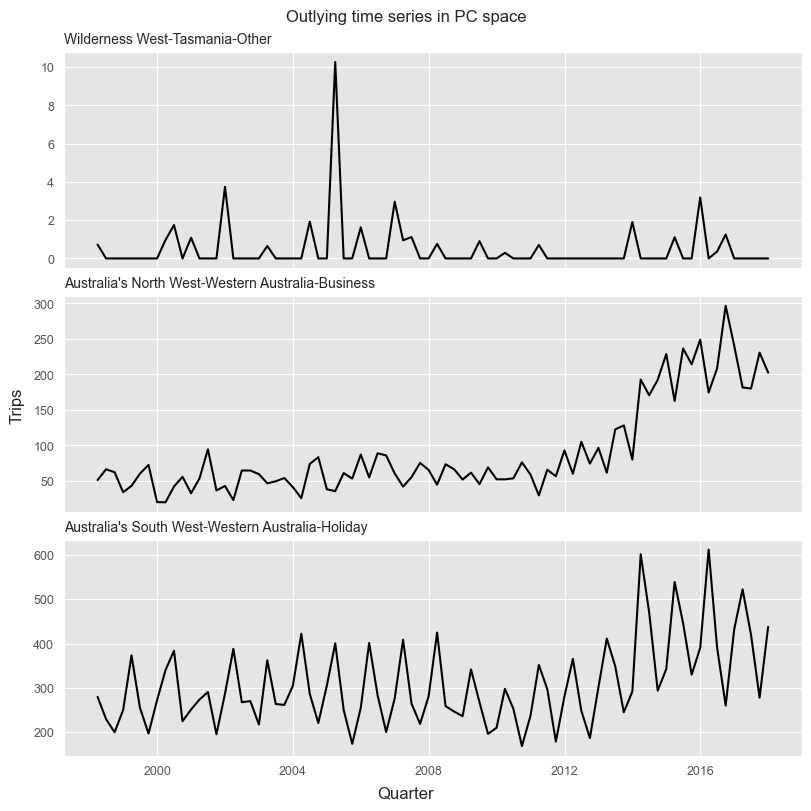

In [15]:
lof = LocalOutlierFactor(n_neighbors=10).fit(pca_df[["PC1", "PC2"]])
res = pca_df.assign(score=lof.negative_outlier_factor_)
selected_ids = res.sort_values("score")["unique_id"].head(3)

fig, axs = plt.subplots(3, figsize=(8, 8), sharex=True)
for (ax, unique_id) in zip(axs, selected_ids):
    df = aus_tourism.loc[lambda x: x["unique_id"] == unique_id]
    ax.plot(df["ds"], df["y"], color="k")
    ax.set_title(unique_id, loc="left", size="medium")

fig.suptitle("Outlying time series in PC space")
fig.supylabel("Trips")
fig.supxlabel("Quarter")
plt.show()